In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [4]:
# ==========================================
# 1. DATA LOADING AND PREPROCESSING
# ==========================================
print("--- [SECTION 1] Loading and Preprocessing Data ---")
df = pd.read_csv('student_data.csv')

# Encoding categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    df[col] = le.fit_transform(df[col].astype(str))

# Create a binary target for Logistic Regression (Pass=1, Fail=0)
pass_threshold = 70
df['Pass_Status'] = (df['Exam_Score'] >= pass_threshold).astype(int)

# Features (X) and separate targets (y)
X = df.drop(['Exam_Score', 'Pass_Status'], axis=1)
y_reg = df['Exam_Score'] # For Linear Regression & NN
y_clf = df['Pass_Status'] # For Logistic Regression

# Define common scaler
scaler = StandardScaler()

--- [SECTION 1] Loading and Preprocessing Data ---



--- [SECTION 2] Linear Regression (Predicting Exam Score) ---
Mean Squared Error: 4.4014
R2 Score: 0.6886


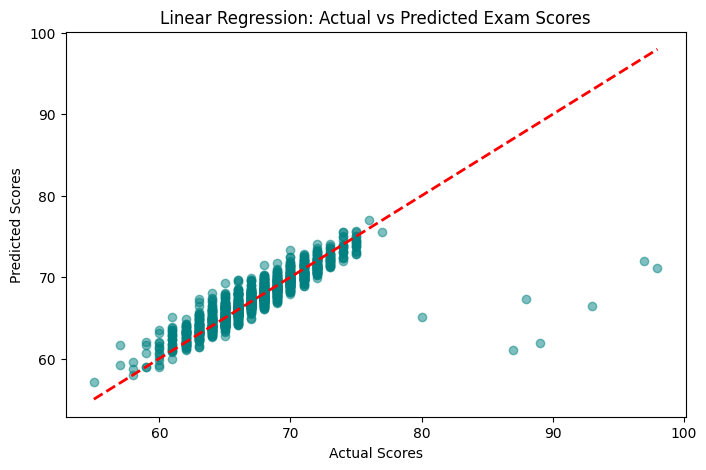

In [5]:
# ==========================================
# 2. LINEAR REGRESSION
# ==========================================
print("\n--- [SECTION 2] Linear Regression (Predicting Exam Score) ---")

# Train-test split for regression
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# Scaling features
X_train_lr_scaled = scaler.fit_transform(X_train_lr)
X_test_lr_scaled = scaler.transform(X_test_lr)

# Model initialization and training
lr_model = LinearRegression()
lr_model.fit(X_train_lr_scaled, y_train_lr)

# Evaluation
y_pred_lr = lr_model.predict(X_test_lr_scaled)
print(f"Mean Squared Error: {mean_squared_error(y_test_lr, y_pred_lr):.4f}")
print(f"R2 Score: {r2_score(y_test_lr, y_pred_lr):.4f}")

# Visualization: Actual vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_test_lr, y_pred_lr, alpha=0.5, color='teal')
plt.plot([y_test_lr.min(), y_test_lr.max()], [y_test_lr.min(), y_test_lr.max()], 'r--', lw=2)
plt.title('Linear Regression: Actual vs Predicted Exam Scores')
plt.xlabel('Actual Scores')
plt.ylabel('Predicted Scores')
plt.show()


--- [SECTION 3] Logistic Regression (Predicting Pass/Fail) ---
Accuracy Score: 0.9168

Classification Report:
              precision    recall  f1-score   support

           0       0.93      0.96      0.94       974
           1       0.88      0.79      0.83       348

    accuracy                           0.92      1322
   macro avg       0.90      0.88      0.89      1322
weighted avg       0.92      0.92      0.92      1322



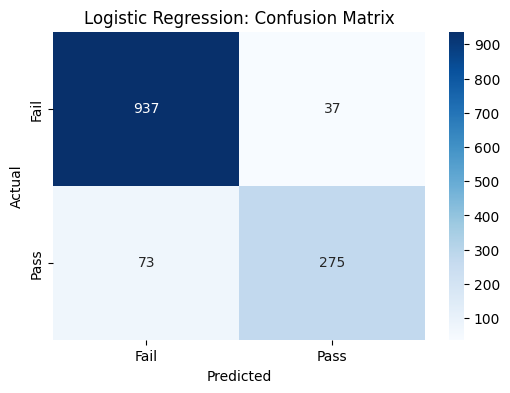

In [6]:
# ==========================================
# 3. LOGISTIC REGRESSION
# ==========================================
print("\n--- [SECTION 3] Logistic Regression (Predicting Pass/Fail) ---")

# Train-test split for classification
X_train_log, X_test_log, y_train_log, y_test_log = train_test_split(X, y_clf, test_size=0.2, random_state=42)

# Scaling features
X_train_log_scaled = scaler.fit_transform(X_train_log)
X_test_log_scaled = scaler.transform(X_test_log)

# Model initialization and training
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_log_scaled, y_train_log)

# Evaluation
y_pred_log = log_reg.predict(X_test_log_scaled)
print(f"Accuracy Score: {accuracy_score(y_test_log, y_pred_log):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_log, y_pred_log))

# Visualization: Confusion Matrix
plt.figure(figsize=(6, 4))
cm = confusion_matrix(y_test_log, y_pred_log)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Fail', 'Pass'], yticklabels=['Fail', 'Pass'])
plt.title('Logistic Regression: Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


--- [SECTION 4] Neural Network (Deep Learning for Exam Score) ---
Training NN Model...


c:\Users\vijay\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Final NN Test Loss (MSE): 5.0899
Final NN Test MAE: 1.1950


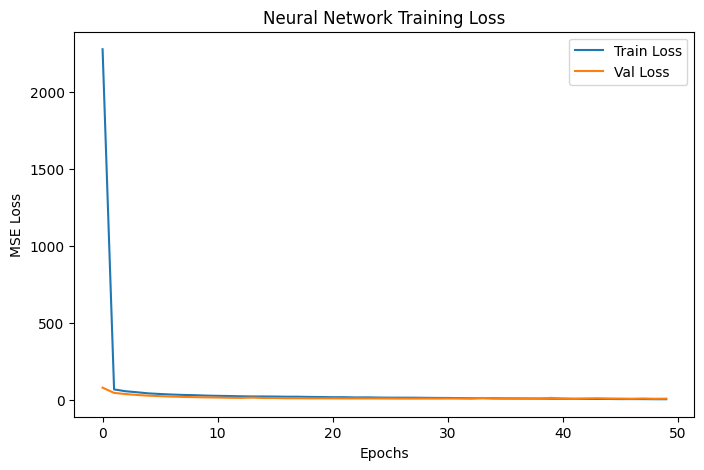


All tasks completed successfully.


In [7]:
# ==========================================
# 4. NEURAL NETWORK (REGRESSION)
# ==========================================
print("\n--- [SECTION 4] Neural Network (Deep Learning for Exam Score) ---")

# Preparing data (reusing scaled data from regression section)
X_train_nn = X_train_lr_scaled
X_test_nn = X_test_lr_scaled
y_train_nn = y_train_lr
y_test_nn = y_test_lr

# Sequential Model Architecture
nn_model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train_nn.shape[1],)),
    Dropout(0.1),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1) # Linear output for regression
])

# Compilation
nn_model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Training
print("Training NN Model...")
history = nn_model.fit(
    X_train_nn, y_train_nn, 
    epochs=50, 
    batch_size=32, 
    validation_split=0.2, 
    verbose=0
)

# Evaluation
nn_eval = nn_model.evaluate(X_test_nn, y_test_nn, verbose=0)
print(f"Final NN Test Loss (MSE): {nn_eval[0]:.4f}")
print(f"Final NN Test MAE: {nn_eval[1]:.4f}")

# Visualization (Loss progression)
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Neural Network Training Loss')
plt.xlabel('Epochs')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

print("\nAll tasks completed successfully.")